In [60]:
from pathlib import Path
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

%load_ext autoreload
%autoreload 2
%matplotlib inline

cwd = Path.cwd().resolve()

# Locate helper_function by searching upward first, then common workspace locations.
def find_helper_folder(start: Path) -> Path:
    # 1) Directly in current/parent tree
    for p in [start, *start.parents]:
        candidate = p / "helper_function"
        if candidate.is_dir():
            return candidate

    raise FileNotFoundError("Could not find helper_function folder")


helper_path = find_helper_folder(cwd)
project_root = helper_path.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
if str(helper_path) not in sys.path:
    sys.path.insert(0, str(helper_path))

print("Project root:", project_root)
print("Current working directory:", cwd)
print("helper_function path:", helper_path)
print("helper_function exists:", helper_path.exists())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root: /Users/JackX/projects/trap_sim_nullspace
Current working directory: /Users/JackX/projects/trap_sim_nullspace/lionix_gate/output_file/dc
helper_function path: /Users/JackX/projects/trap_sim_nullspace/helper_function
helper_function exists: True


In [61]:
charge = 1.602176634e-19  # Coulombs
mass = 40 * 1.66053906660e-27  # kg (mass of Ca+ ion)
Omega = 2 * np.pi * 50e6  # rad/s (RF drive frequency)
pseudo_factor = charge / (4 * mass * Omega**2)

## Get grad and hessian of potential for each electrodes at x0, y0, z0

In [78]:
from post_processing import read_post_processed
from field_analysis import analyze_dc_pot

electrode_num = 27
rf_electrode_index = [13]
gnd_electrode_index = [1, 2, 14, 20, 26, 27]
excitation_electrodes = set(range(1, electrode_num + 1)) - set(gnd_electrode_index) - set(rf_electrode_index)
print("DC Excitation Electrodes:", excitation_electrodes)
excitation_electrodes = sorted(excitation_electrodes)
x, y, z, potentials = read_post_processed(filename="dc_sim_out.h5", electrode_names=list(excitation_electrodes))

x_axis = x[:, 0, 0]
y_axis = y[0, :, 0]
z_axis = z[0, 0, :]

DC Excitation Electrodes: {3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 15, 16, 17, 18, 19, 21, 22, 23, 24, 25}


In [81]:
n_points = 10

x0 = 0
y0 = 0
z0 = 49.99e-6

x0_index = jnp.argmin(jnp.abs(x_axis - x0))
y0_index = jnp.argmin(jnp.abs(y_axis - y0))
z0_index = jnp.argmin(jnp.abs(z_axis - z0))

# Index window around each center
half = max(0, n_points // 2)
ix_start = max(0, x0_index - half)
ix_end = min(x_axis.shape[0], x0_index + half + 1)
iy_start = max(0, y0_index - half)
iy_end = min(y_axis.shape[0], y0_index + half + 1)
iz_start = max(0, z0_index - half)
iz_end = min(z_axis.shape[0], z0_index + half + 1)

ix = jnp.arange(ix_start, ix_end)
iy = jnp.arange(iy_start, iy_end)
iz = jnp.arange(iz_start, iz_end)

# Windowed yz grid and pseudo-potential
X_abs = x[np.ix_(ix, iy, iz)]
Y_abs = y[np.ix_(ix, iy, iz)]
Z_abs = z[np.ix_(ix, iy, iz)]

dc_fields = {}


for i in excitation_electrodes:
    potential = potentials[i][np.ix_(ix, iy, iz)]
    
    coeff, phi, grad, hessian = analyze_dc_pot(X_abs, Y_abs, Z_abs, potential, x0, y0, z0)

    dc_fields[i] = (coeff, phi, grad, hessian)

In [82]:
dc_fields = {}

x0 = 0
y0 = 0
z0 = 49.99e-6

dr = 1e-6

for i in excitation_electrodes:
    
    coeff, phi, grad, hessian = analyze_dc_pot(x, y, z, potentials[i], x0, y0, z0, dr)

    dc_fields[i] = (coeff, phi, grad, hessian)

To achieve axial trapping of ion at x0, y0, and z0 with $\omega_0 = 2 \pi\times1$ MHz, we would have grad = [0, 0, 0], hessian = $\alpha$ [[1, 0, 0], [0, -1/2, 0], [0, 0, -1/2]], with $\alpha = \frac{m \omega_0^2}{q}$

In [83]:
from field_analysis import fit_prep, print_field

omega = 2 * np.pi * 1e6

A, b = fit_prep(dc_fields, excitation_electrodes, target_phi = np.array([0]), target_grad = np.array([0,0,0]), target_hessian = np.array([[1, 0, 0], [0, -1/2, 0], [0, 0, -1/2]])*mass*omega**2/(charge))

In [84]:
coeff, *_ = jnp.linalg.lstsq(A, b, rcond=None)

In [85]:
for i in range(len(coeff)):
    print(excitation_electrodes[i], coeff[i])
print_field(A@coeff, delta_pos=True)

3 -1.9578198681969903
4 -2.5933169534211173
5 -2.378249463374923
6 3.411127819373392
7 -1.7484580207765954
8 3.4039077413093164
9 -2.372406587004985
10 -2.5675259218879907
11 -1.9265695865403414
12 -0.0070064624163840225
15 -0.006921002250810538
16 -1.9595903198489992
17 -2.5917217712639995
18 -2.3813615472455254
19 3.407821290050431
21 -1.7440055684980464
22 3.395785649447935
23 -2.366030379904415
24 -2.5768222461781676
25 -1.91849723666478
Phi: 6.840329207951409e-09
Grad: [-3.07550374e-09  5.51312951e-08 -1.26442856e-10]
Hessian: [[ 1.63665986e+07  2.21189111e-09 -5.29325916e-10]
 [ 2.21189111e-09 -8.18329931e+06 -1.71363354e-07]
 [-5.29325916e-10 -1.71363354e-07 -8.18329931e+06]]
Delta Pos (um): [ 1.87913433e-10  6.73704981e-09 -1.54513298e-11]


Now to compare with voltage sets from before, using 5 electrodes from each side : 5, 6, 7, 8, 9, 18, 19, 21, 22, 23 and 12, 15 at the center

In [70]:
selected_electrodes = [5, 6, 7, 8, 9, 12, 15, 18, 19, 21, 22, 23]

In [71]:
omega = 2 * np.pi * 1e6
A, b = fit_prep(dc_fields, selected_electrodes, target_phi = None, target_grad = np.array([0,0,0]), target_hessian = np.array([[1, 0, 0], [0, -1/2, 0], [0, 0, -1/2]])*mass*omega**2/(charge))
coeff, *_ = jnp.linalg.lstsq(A, b, rcond=1e-10)

In [72]:
for i in range(len(coeff)):
    print(selected_electrodes[i], coeff[i])
print_field(A@coeff, delta_pos=True)

5 0.2896169383586322
6 0.5415987706662609
7 -2.1551389198012743
8 0.5400520649413059
9 0.3000511658873237
12 -0.2693633414144604
15 -0.2698205371676484
18 0.28984338977324725
19 0.541931824807605
21 -2.155386963921642
22 0.5387789633018708
23 0.29989075174768487
Grad: [ 1.79539522e-10 -9.32914190e-10 -1.23293109e-09]
Hessian: [[ 1.63665986e+07 -3.39969120e-08  2.26236807e-10]
 [-3.39969120e-08 -8.18329931e+06  1.11758709e-08]
 [ 2.26236807e-10  1.11758709e-08 -8.18329931e+06]]
Delta Pos (um): [-1.09698738e-11 -1.14002208e-10 -1.50664303e-10]


In [52]:
potential_space = np.zeros_like(x)

for i in range(len(coeff)):

    electrode_i = selected_electrodes[i]
    potential_space = potential_space + coeff[i] *  potentials[electrode_i]

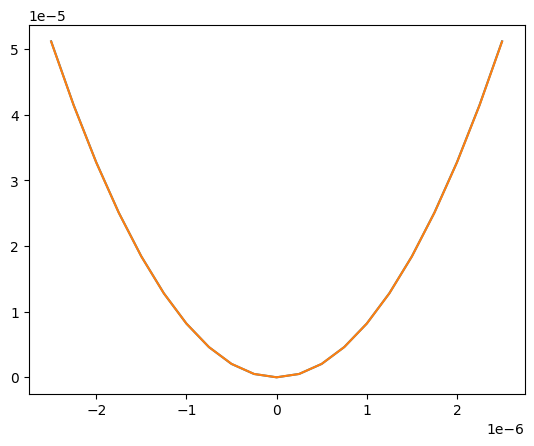

In [56]:
target_hessian = np.array([[1, 0, 0], [0, -1/2, 0], [0, 0, -1/2]])*mass*omega**2/(charge)
plt.plot(x_axis, potential_space[:, y0_index, z0_index]-min(potential_space[:, y0_index, z0_index]))
plt.plot(x_axis,1/2*target_hessian[0,0]*(x_axis-0)**2)

Compare to voltage sets we've been using.

In [206]:
x_anstaz = np.array([5.006, -2.408, -2.408, -2.408, 5.006, -0.604, -0.604, 5.006, -2.408, -2.408, -2.408, 5.006])
print_field(A @ x_anstaz, delta_pos=True)

Grad: [ -0.49604095   2.29139475 416.86133699]
Hessian: [[ 1.69271772e+07 -3.15080435e+03 -1.52258670e+04]
 [-3.15080435e+03  8.12344253e+06 -7.28496891e+04]
 [-1.52258670e+04 -7.28496891e+04 -2.50506197e+07]]
Delta Pos (um): [ 0.04424825 -0.13281992 16.6411188 ]


In [207]:
x_anstaz = np.array([0, 0.58095, -1.6915,0.58095, 0, -0.24083, -0.24083, 0, 0.58095, -1.6915,0.58095, 0])
print_field(A @ x_anstaz, delta_pos=True)

Grad: [ -0.35848744   0.7828535  214.24438414]
Hessian: [[ 1.29363356e+07  4.47644404e+03 -8.46184502e+03]
 [ 4.47644404e+03 -2.61246321e+04 -2.20522000e+04]
 [-8.46184502e+03 -2.20522000e+04 -1.29102110e+07]]
Delta Pos (um): [ 0.03301679 15.98677726 16.56762713]


In [ ]:
def trajectory_sol(t):

## Fit to a given potential function $f(x)$ with region of interest of width $R$

In [10]:
from post_processing import read_post_processed
from field_analysis import analyze_dc_pot

electrode_num = 27
rf_electrode_index = [13]
gnd_electrode_index = [1, 2, 14, 20, 26, 27]
excitation_electrodes = set(range(1, electrode_num + 1)) - set(gnd_electrode_index) - set(rf_electrode_index)
print("DC Excitation Electrodes:", excitation_electrodes)
excitation_electrodes = sorted(excitation_electrodes)
x, y, z, potentials = read_post_processed(filename="dc_transport_sim_out.h5", electrode_names=list(excitation_electrodes))

x_axis = x[:, 0, 0]
y_axis = y[0, :, 0]
z_axis = z[0, 0, :]

DC Excitation Electrodes: {3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 15, 16, 17, 18, 19, 21, 22, 23, 24, 25}


In [11]:
print(x_axis)

[-2.50e-06 -2.25e-06 -2.00e-06 -1.75e-06 -1.50e-06 -1.25e-06 -1.00e-06
 -7.50e-07 -5.00e-07 -2.50e-07  0.00e+00  2.50e-07  5.00e-07  7.50e-07
  1.00e-06  1.25e-06  1.50e-06  1.75e-06  2.00e-06  2.25e-06  2.50e-06]
